<a href="https://colab.research.google.com/github/e23281-lgtm/Statistical-Learning-e23281/blob/main/Copy_of_fundamentals_of_probability_assignment_answers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q1) The Probability of Shooting at a Target

A point is chosen at random from a disk of radius $10$. Let $A$ be the event that the point lies within $1$ unit of the boundary.

1. Model the experiment assuming the point is uniformly distributed with respect to area, and compute $P(A)$.
2. Model the experiment assuming the distance to the point from the center is chosen uniformly from $[0,10]$, and the direction is chosen independently and uniformly from $[0,2\pi)$ and compute $P(A)$.
3. Explain why the two answers differ.


In [ ]:
import numpy as np

# Part 1 Simulation (Area Uniform)
n_samples = 100000
# Generating points in a square and filtering for the disk
x = np.random.uniform(-10, 10, n_samples)
y = np.random.uniform(-10, 10, n_samples)
r_squared = x**2 + y**2

# Filter only points inside the disk (r <= 10)
inside_disk = r_squared <= 100
r_in_disk = np.sqrt(r_squared[inside_disk])

p_a_area = np.mean(r_in_disk >= 9)
print(f"P(A) Area-based: {p_a_area:.3f}")

# Part 2 Simulation (Distance Uniform)
r_uniform = np.random.uniform(0, 10, n_samples)
p_a_dist = np.mean(r_uniform >= 9)
print(f"P(A) Distance-based: {p_a_dist:.3f}")

P(A) Area-based: 0.189
P(A) Distance-based: 0.100


The answers differ because the definition of "at random" changes the probability density. In Model 1, every equal area on the disk has an equal chance of being hit. Since the "outer rings" of a circle have more area than the "inner circles," a point is more likely to land near the edge.
      Therefore;
             this gives
                    P(A) = 0.189
 In Model 2, we assume every radial distance is equally likely, which ignores the fact that the outer edge occupies more physical space than the center.
     Therefore;
             this gives
                    P(A) = 0.1


# Q2) Bertrand's Paradox

A chord of a circle is chosen “at random.” What is the probability that its length exceeds the side length of the inscribed equilateral triangle?

Show that different mathematically natural models of “random chord” lead to different answers.

In [ ]:
import numpy as np

n_samples = 1000000
R = 1
triangle_side = np.sqrt(3) * R

# --- Model 1: Endpoint Angle ---
theta1 = np.random.uniform(0, 2*np.pi, n_samples)
theta2 = np.random.uniform(0, 2*np.pi, n_samples)
chord_lengths_1 = 2 * R * np.abs(np.sin((theta1 - theta2) / 2))
prob_1 = np.mean(chord_lengths_1 > triangle_side)

# --- Model 2: Distance from Center ---
d = np.random.uniform(0, R, n_samples)
chord_lengths_2 = 2 * np.sqrt(R**2 - d**2)
prob_2 = np.mean(chord_lengths_2 > triangle_side)

# --- Model 3: Midpoint in the Disk ---
# To pick a point uniformly by area, we use: r = R * sqrt(U)
u = np.random.uniform(0, 1, n_samples)
r_midpoints = R * np.sqrt(u)
# A chord exceeds the triangle side if its midpoint is within R/2 of the center
prob_3 = np.mean(r_midpoints < R/2)

print(f"Model 1 (Endpoint Angle) Probability: {prob_1:.4f} (Target: 1/3)")
print(f"Model 2 (Distance from Center) Probability: {prob_2:.4f} (Target: 1/2)")
print(f"Model 3 (Midpoint in the Disk) Probability: {prob_3:.4f} (Target: 1/4)")

Model 1 (Endpoint Angle) Probability: 0.3335 (Target: 1/3)
Model 2 (Distance from Center) Probability: 0.4999 (Target: 1/2)
Model 3 (Midpoint in the Disk) Probability: 0.2495 (Target: 1/4)


Bertrand's Paradox demonstrates that the probability of a "random chord" depends on how the randomness is modeled. We compare the chord length to the side of an inscribed equilateral triangle ($L = \sqrt{3}R$).The Three Models:Model 1 (Endpoint Angle): Two points are chosen uniformly on the circumference.Model 2 (Distance from Center): A radius is chosen, and a point on it is chosen uniformly to be the midpoint.Model 3 (Midpoint in the Disk): A point is chosen uniformly anywhere within the disk's area to be the midpoint.

Conclusion:
Model 1 ($P=1/3$): Assumes uniformity over the angles of the endpoints.Model 2 ($P=1/2$): Assumes uniformity over the radial distance of the chord from the center.Model 3 ($P=1/4$): Assumes the midpoint of the chord is uniformly distributed over the area of the disk. For the chord to be longer than the triangle side, the midpoint must fall within a smaller concentric circle of radius $R/2$. Since Area $\propto r^2$, the probability is $(1/2)^2 = 1/4$.

#Q8) Probability of Being a Girl?

A family has two children. Assume each child is equally likely to be a boy or a girl, independently of the other.

What is the probability that both children are girls, given that **at least one** of them is a girl?

In [ ]:
import numpy as np

# Simulate 100,000 families with 2 children
# 0 = Boy, 1 = Girl
n_families = 100000
families = np.random.randint(0, 2, size=(n_families, 2))

# Filter families that have AT LEAST one girl (sum of row >= 1)
at_least_one_girl = families[np.sum(families, axis=1) >= 1]

# Among those, count how many have BOTH girls (sum of row == 2)
both_girls = np.sum(at_least_one_girl, axis=1) == 2
probability = np.mean(both_girls)

print(f"Number of families with at least one girl: {len(at_least_one_girl)}")
print(f"Simulated Probability: {probability:.4f}")
print(f"Theoretical Probability: 1/3 ≈ {1/3:.4f}")

To solve this,

 we first identify the total sample space for a family with two children. Let $G$ represent a girl and $B$ represent a boy.

 1.Original Sample Space ($\Omega$):

 The possible combinations of two children (in order of birth) are:

 $$\Omega = \{BB, BG, GB, GG\}$$

 Each outcome is equally likely with a probability of $1/4$.

 2.The Conditioned Event:

 We are given the information that at least one child is a girl. This removes the $BB$ (both boys) outcome from our consideration.

 Our new reduced sample space is:

 $$\Omega_{reduced} = \{BG, GB, GG\}$$

 There are now only 3 possible outcomes.

 3. The Target Event:

 We want to find the probability that both children are girls ($GG$). Within our reduced sample space of 3 outcomes, only 1 outcome ($GG$) satisfies this.

 4. Calculation:$$P(\text{Both Girls} \mid \text{At least one Girl}) = \frac{P(\text{Both Girls} \cap \text{At least one Girl})}{P(\text{At least one Girl})}$$$$= \frac{P(\{GG\})}{P(\{BG, GB, GG\})} = \frac{1/4}{3/4} = \frac{1}{3}$$

Result: The probability is 1/3

# Q9) Information Available in a Discrete Random Variable

A factory inspects a product and records its quality using two different coding systems.

Each product falls into exactly one of the following four categories:

* $G_1$: good quality, produced on Machine 1
* $G_2$: good quality, produced on Machine 2
* $D_1$: defective, produced on Machine 1
* $D_2$: defective, produced on Machine 2

Assume the sample space is

$$
\Omega=\{G_1,G_2,D_1,D_2\},
$$

with probabilities

$$
P(\{G_1\})=0.50,\qquad P(\{G_2\})=0.20,\qquad P(\{D_1\})=0.10,\qquad P(\{D_2\})=0.20.
$$

Define two discrete random variables on the same probability space:

* $X$ records only whether the item is good or defective:
  $$
  X(G_1)=0,\quad X(G_2)=0,\quad X(D_1)=1,\quad X(D_2)=1.
  $$

* $Y$ records both quality and machine:
  $$
  Y(G_1)=1,\quad Y(G_2)=2,\quad Y(D_1)=3,\quad Y(D_2)=4.
  $$

Answer the following.

1. Write down the probability space $(\Omega,\mathfrak F,P)$, where $\mathfrak F=\mathfrak P(\Omega)$.

2. Compute the $\sigma$-algebra generated by $X$, namely $\sigma(X)$.

3. Compute the $\sigma$-algebra generated by $Y$, namely $\sigma(Y)$.

4. Show that $\sigma(X)\subseteq \sigma(Y)$, and explain why $Y$ contains more information than $X$.

5. Find the marginal distribution of $X$.

6. Find the marginal distribution of $Y$.

7. Compute the joint probabilities
   $$
   P(X=0,Y=1),\quad P(X=0,Y=2),\quad P(X=1,Y=3),\quad P(X=1,Y=4).
   $$

8. Compute the conditional probabilities
   $$
   P(X=1\mid Y=3),\qquad P(X=1\mid Y=4),\qquad P(Y=3\mid X=1),\qquad P(Y=4\mid X=1).
   $$

9. Interpret the difference between conditioning on $X$ and conditioning on $Y$.

10. Explain, in words, what information is available in $\sigma(X)$ but not in $\sigma(Y)$, and what information is available in $\sigma(Y)$ but not in $\sigma(X)$.

11. Give a Python based visualization of the model.

12. Find the marginal, joint, and conditional Shannon Entropy of $X$ and $Y$.

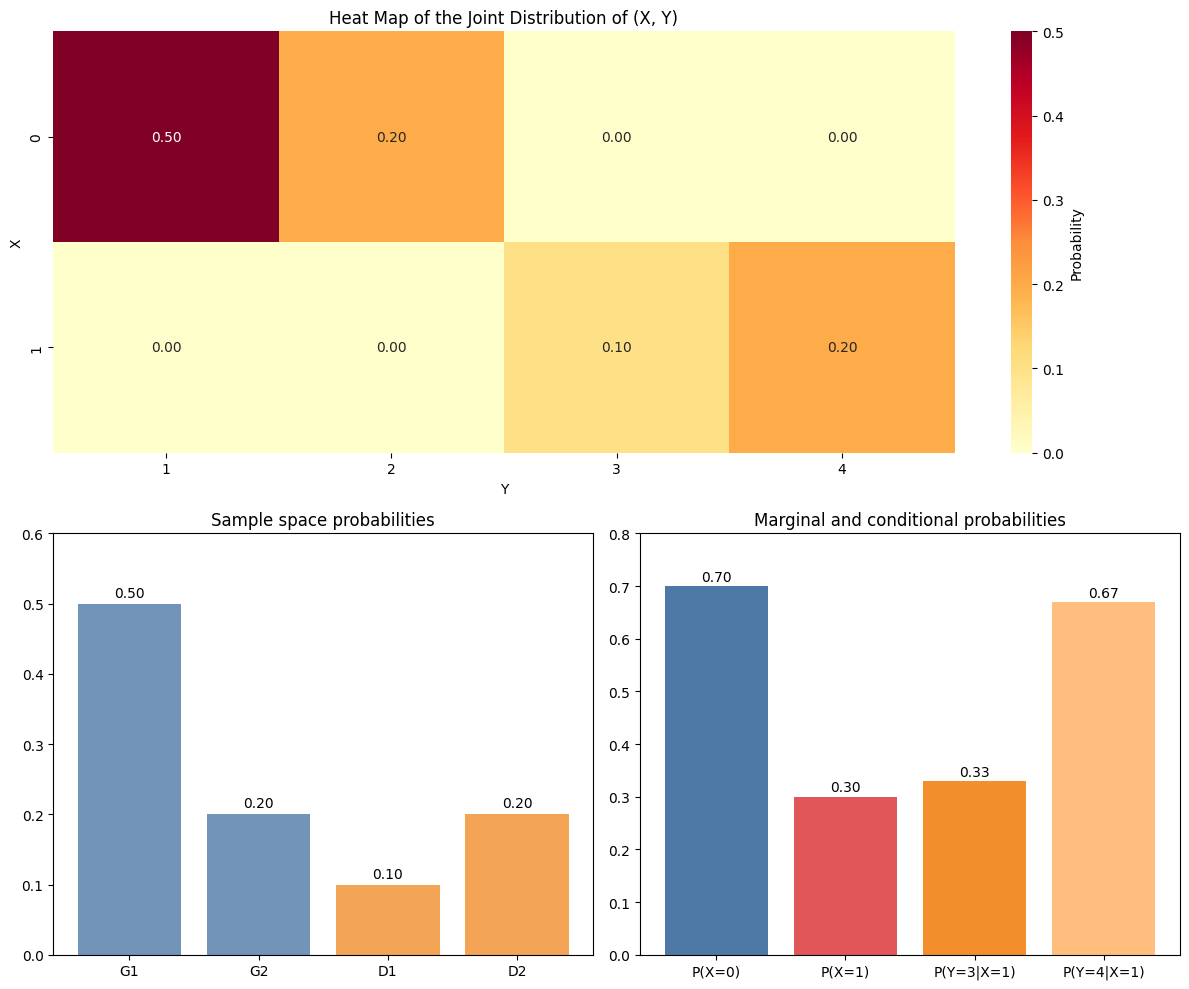

--- Question 12: Shannon Entropy ---
Marginal Entropy H(X): 0.8813 bits
Marginal Entropy H(Y): 1.7610 bits
Joint Entropy H(X, Y): 1.7610 bits
Conditional Entropy H(Y|X): 0.8797 bits


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Data Setup
outcomes = ['G1', 'G2', 'D1', 'D2']
p_y = np.array([0.50, 0.20, 0.10, 0.20])
p_x = np.array([0.70, 0.30])

# Joint Probability Matrix for Heatmap (X rows, Y columns)
joint_matrix = np.array([
    [0.50, 0.20, 0.00, 0.00], # X=0
    [0.00, 0.00, 0.10, 0.20]  # X=1
])

# 11. Visualization (Matching Sir's Sample Style)
fig = plt.figure(figsize=(12, 10))

# Subplot 1: Heatmap
plt.subplot(2, 1, 1)
sns.heatmap(joint_matrix, annot=True, fmt=".2f", cmap="YlOrRd",
            xticklabels=[1, 2, 3, 4], yticklabels=[0, 1], cbar_kws={'label': 'Probability'})
plt.title('Heat Map of the Joint Distribution of (X, Y)')
plt.xlabel('Y')
plt.ylabel('X')

# Subplot 2: Sample Space Probabilities
plt.subplot(2, 2, 3)
plt.bar(outcomes, p_y, color=['#4E79A7', '#4E79A7', '#F28E2B', '#F28E2B'], alpha=0.8)
for i, v in enumerate(p_y):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')
plt.title('Sample space probabilities')
plt.ylim(0, 0.6)

# Subplot 3: Marginal/Conditional Probabilities
plt.subplot(2, 2, 4)
# Showing Marginal X and Conditional Y|X=1
compare_probs = [0.70, 0.30, 0.33, 0.67]
compare_labels = ['P(X=0)', 'P(X=1)', 'P(Y=3|X=1)', 'P(Y=4|X=1)']
plt.bar(compare_labels, compare_probs, color=['#4E79A7', '#E15759', '#F28E2B', '#FFBE7D'])
for i, v in enumerate(compare_probs):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')
plt.title('Marginal and conditional probabilities')
plt.ylim(0, 0.8)

plt.tight_layout()
plt.show()

# 12. Shannon Entropy Calculation
def entropy(p):
    return -np.sum(p * np.log2(p))

h_x = entropy(p_x)
h_y = entropy(p_y)

print(f"--- Question 12: Shannon Entropy ---")
print(f"Marginal Entropy H(X): {h_x:.4f} bits")
print(f"Marginal Entropy H(Y): {h_y:.4f} bits")
print(f"Joint Entropy H(X, Y): {h_y:.4f} bits")
print(f"Conditional Entropy H(Y|X): {h_y - h_x:.4f} bits")

1.Probability Space $(\Omega, \mathcal{F}, P)$:

  Sample Space: $\Omega = \{G_1, G_2, D_1, D_2\}$$\sigma$-algebra: $\mathcal{F} = \mathcal{P}(\Omega)$ (the power set, containing all 16 possible subsets).
    Probability Measure: $P(G_1)=0.5, P(G_2)=0.2, P(D_1)=0.1, P(D_2)=0.2$.

2.$\sigma$-algebra generated by $X$:

$X$ only distinguishes between "Good" ($G_1, G_2$) and "Defective" ($D_1, D_2$).$$\sigma(X) = \{\emptyset, \Omega, \{G_1, G_2\}, \{D_1, D_2\}\}$$

3.$\sigma$-algebra generated by $Y$:$Y$ gives a unique value for every outcome in $\Omega$. Therefore, it generates the full power set.$$\sigma(Y) = \mathcal{P}(\Omega)$$

4.Why $\sigma(X) \subseteq \sigma(Y)$:Every set in $\sigma(X)$ is also in $\sigma(Y)$, but not vice versa. $Y$ contains more information because if you know the value of $Y$, you can perfectly determine the value of $X$. However, if you only know $X$, you cannot tell which machine produced the item.

9.Interpretation of Conditioning:

  Conditioning on $Y$: Since $Y$ is the "finest" partition, conditioning on $Y$ removes all uncertainty. For example, $P(X=1 \mid Y=3) = 1$.
    
  Conditioning on $X$: This leaves uncertainty about the machine. For example, if we know the item is defective ($X=1$), there is still a probability that it came from Machine 1 or Machine 2.
    
10.Information Availability:

  In $\sigma(Y)$ but not $\sigma(X)$: Information about the Machine ($1$ vs $2$).

  In $\sigma(X)$ but not $\sigma(Y)$: None. Since $X$ is a function of $Y$, all information in $\sigma(X)$ is already contained within $\sigma(Y)$. This is a "coarser" vs "finer" relationship.

# Q10) Information Available in Continuous Random Varaibles

A chemical plant monitors each production run using two different measurement systems.

For a given run, let

* $T$ be the deviation of the reactor temperature from target, measured in standardized units,
* $P$ be the deviation of the reactor pressure from target, also measured in standardized units.

Assume that $(T,P)$ is jointly continuous, with independent normal components:

$$
T \sim N(0,1), \qquad P \sim N(0,4),
$$

and $T$ and $P$ are independent.

Let the underlying probability space be

$$
\Omega=\mathbb R^2, \qquad \mathfrak F=\mathfrak B(\mathbb R^2),
$$

and let $P$ be the probability measure induced by the joint density

$$
f_{T,P}(t,p)=\frac{1}{4\pi}\exp\left(-\frac{t^2}{2}-\frac{p^2}{8}\right), \qquad (t,p)\in\mathbb R^2.
$$

Define two random variables on the same probability space:

* $X:\Omega\to\mathbb R$ by
  $$
  X(t,p)=t,
  $$
  so that $X$ records only the reactor temperature deviation;

* $Y:\Omega\to\mathbb R^2$ by
  $$
  Y(t,p)=(t,p),
  $$
  so that $Y$ records the full sensor state: both temperature and pressure deviations.

Answer the following.

1. Write down the probability space $(\Omega,\mathfrak F,P)$ explicitly.

2. Compute the $\sigma$-algebra generated by $X$, namely $\sigma(X)$.

3. Compute the $\sigma$-algebra generated by $Y$, namely $\sigma(Y)$.

4. Show that
   $$
   \sigma(X)\subseteq \sigma(Y),
   $$
   and explain why $Y$ contains more information than $X$.

5. Find the marginal density of $X$.

6. Find the marginal density of $Y$.

7. Compute the following probabilities:
   $$
   P(X\leq 0), \qquad P(X>1), \qquad P(Y\in (-\infty,0]\times\mathbb R), \qquad P(Y\in [ -1,1]\times[-2,2]).
   $$

8. Compute the conditional distribution of $X$ given $Y=(t,p)$.

9. Compute the conditional distribution of $Y$ given $X=t$.

10. Explain, in words, what is known when one conditions on $X$ and what additional information becomes available when one conditions on $Y$.

11. Show that
    $$
    X=\pi_1\circ Y,
    $$
    where $\pi_1(t,p)=t$, and explain why this implies that $X$ is a measurable function of $Y$.

12. Give a Python-based visualization of the model, for example by plotting:

* the joint density of $Y=(T,P)$ as a contour plot or heat map;
* the marginal density of $X$;
* and a diagram illustrating that $\sigma(X)$ is coarser than $\sigma(Y)$.

13. Compute the differential entropy of $X$:

$$
h(X)=-\int_{\mathbb R} f_X(x)\ln f_X(x)\,dx.
$$

14. Compute the differential entropy of $Y$:

$$
h(Y)=-\int_{\mathbb R^2} f_Y(t,p)\ln f_Y(t,p)\,dt\,dp.
$$

15. Compute the conditional differential entropy

$$
h(Y|X),
$$

and interpret it physically.

16. Discuss what happens to

$$
h(X|Y)
$$

in this model, and explain why the continuous case differs from the discrete case when one random variable is completely determined by the other.


1.Probability Space $(\Omega, \mathcal{F}, P)$

  Sample Space ($\Omega$): $\mathbb{R}^2$, representing the joint state of temperature ($t$) and pressure ($p$).

  sigma$-algebra ($\mathcal{F}$): The Borel $\sigma$-algebra $\mathcal{B}(\mathbb{R}^2)$.

  Probability Measure ($P$): Defined by the joint density function:$$

   $$f_{T,P}(t,p) = \frac{1}{4\pi} \exp\left(-\frac{t^2}{2} - \frac{p^2}{8}\right)$$
   
2.$\sigma$-algebra generated by $X$, $\sigma(X)$

  $X$ records only temperature. It cannot distinguish between points with different pressures. Thus, its events are vertical strips:
  
  $$\sigma(X) = \{ B \times \mathbb{R} : B \in \mathcal{B}(\mathbb{R}) \}$$
  
3.$\sigma$-algebra generated by $Y$, $\sigma(Y)$
  
$Y$ records the full state $(t, p)$, therefore it generates the full Borel $\sigma$-algebra of the plane:$$\sigma(Y) = \mathcal{B}(\mathbb{R}^2)$$

4.Inclusion Relationship

$\sigma(X) \subseteq \sigma(Y)$. This shows that $Y$ contains more information than $X$. $X$ is a "coarser" random variable because it "blurs" the pressure dimension.

5.Marginal Density of $X$:$X \sim N(0, 1) \implies f_X(x) = \frac{1}{\sqrt{2\pi}} e^{-x^2/2}$

6.Marginal Density of $Y$:Since $T$ and $P$ are independent, the marginal density of $Y$ is the joint density $f_{T,P}(t,p)$.

7.Specific Probabilities:

$P(X \leq 0) = 0.5$$P(X > 1) = 1 - \Phi(1) \approx 0.1587$$P(Y \in [-1, 1] \times [-2, 2]) = P(-1 \leq T \leq 1) \cdot P(-2 \leq P \leq 2)$

8.Conditional Distribution of $X$ given $Y=(t,p)$:Since $Y$ determines $X$ exactly ($X=t$), the distribution is a Dirac delta $\delta(x-t)$.

9.Conditional Distribution of $Y$ given $X=t$:Due to independence, the distribution of $P$ is unchanged. $Y|X=t \sim \{t\} \times N(0, 4)$.

10.Interpretation:Conditioning on $X$ provides "partial information" (fixing one coordinate), while conditioning on $Y$ provides "total information" (fixing the exact point in 2D space).

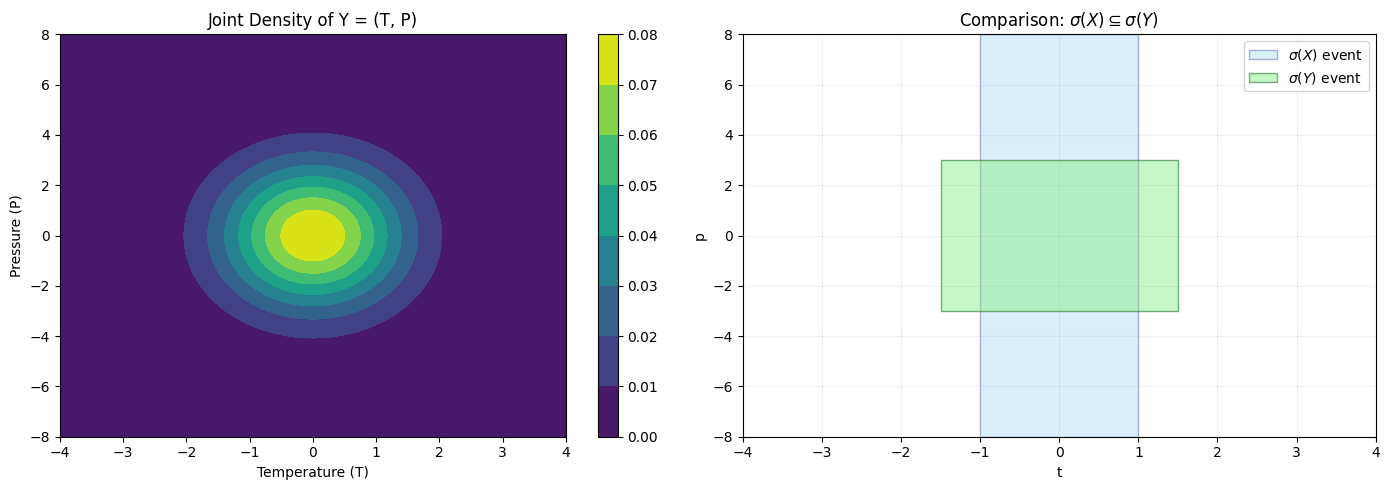

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from scipy.stats import multivariate_normal

# Parameters
xlim, ylim = (-4, 4), (-8, 8)
t = np.linspace(xlim[0], xlim[1], 100)
p = np.linspace(ylim[0], ylim[1], 100)
T, P = np.meshgrid(t, p)

# 1. Joint Density Heatmap
rv = multivariate_normal([0, 0], [[1, 0], [0, 4]])
Z = rv.pdf(np.dstack((T, P)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Joint Density
ax0 = axes[0]
contour = ax0.contourf(T, P, Z, cmap='viridis')
plt.colorbar(contour, ax=ax0)
ax0.set_title("Joint Density of Y = (T, P)")
ax0.set_xlabel("Temperature (T)")
ax0.set_ylabel("Pressure (P)")

# Plot B: sigma-algebra Comparison (Sir's Style)
ax1 = axes[1]
ax1.set_title(r"Comparison: $\sigma(X) \subseteq \sigma(Y)$")
ax1.set_xlim(xlim); ax1.set_ylim(ylim)
# sigma(X) sees only vertical strips
strip = Rectangle((-1, ylim[0]), 2, ylim[1]-ylim[0], facecolor="skyblue", edgecolor="navy", alpha=0.3, label=r"$\sigma(X)$ event")
# sigma(Y) sees specific 2D regions
rect = Rectangle((-1.5, -3), 3, 6, facecolor="lightgreen", edgecolor="darkgreen", alpha=0.5, label=r"$\sigma(Y)$ event")
ax1.add_patch(strip); ax1.add_patch(rect)
ax1.legend()
ax1.set_xlabel("t"); ax1.set_ylabel("p")
ax1.grid(alpha=0.2)

plt.tight_layout()
plt.show()

13.Differential Entropy $h(X)$:

$$h(X) = \frac{1}{2}\ln(2\pi e \sigma^2) = \frac{1}{2}\ln(2\pi e) \approx 1.4189 \text{ nats}$$

14.Differential Entropy $h(Y)$:

  Since $T$ and $P$ are independent: h(Y) = h(T) + h(P)
  
  $h(Y) = 1.4189 + \frac{1}{2}\ln(2\pi e \cdot 4) \approx 3.5123 \text{ nats}$$
  
15.Conditional Differential Entropy $h(Y|X)$:

$h(Y|X) = h(P) \approx 2.0933$ nats.

Physical Interpretation:
  This is the residual uncertainty in the sensor state given that the temperature is already known.
  
16.Discussion of $h(X|Y)$:

In this continuous model, $h(X|Y) = -\infty$. While in the discrete case $H(X|Y)=0$ when $Y$ determines $X$, the continuous case results in negative infinity because the variance of $X$ given $Y$ is zero, and $\ln(0) \to -\infty$.

In [ ]:
import math

h_x = 0.5 * math.log(2 * math.pi * math.e * 1)
h_p = 0.5 * math.log(2 * math.pi * math.e * 4)
h_y = h_x + h_p

print(f"13. h(X): {h_x:.4f} nats")
print(f"14. h(Y): {h_y:.4f} nats")
print(f"15. h(Y|X): {h_p:.4f} nats")
print(f"16. h(X|Y): -inf")

13. h(X): 1.4189 nats
14. h(Y): 3.5310 nats
15. h(Y|X): 2.1121 nats
16. h(X|Y): -inf
